# Proyecto Final Data Mining
## Análisis de Ventas de Videojuegos
### Dataset: vgsales.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

In [7]:
df = pd.read_csv('/Users/loren/Documents/GitHub/Proyecto-1---Data-mining/data/vgsales.csv', sep=',')
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [8]:
print("Filas y columnas:", df.shape)
print("\nTipos de variables:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Filas y columnas: (16598, 11)

Tipos de variables:
Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

Valores nulos por columna:
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


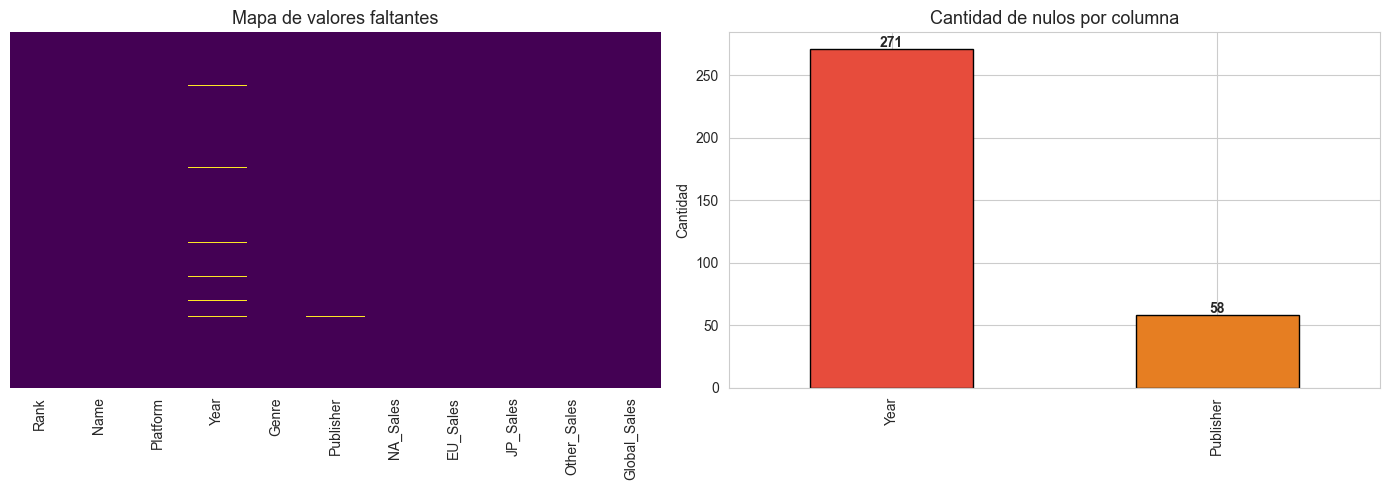

In [ ]:
import missingno as msno
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df.isnull(), cbar=False, ax=axes[0], 
            yticklabels=False, cmap='viridis')
axes[0].set_title('Mapa de valores faltantes', fontsize=13)
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
nulos.plot(kind='bar', ax=axes[1], color=['#E74C3C', '#E67E22'], edgecolor='black')
axes[1].set_title('Cantidad de nulos por columna', fontsize=13)
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(nulos):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
print("Estadísticas básicas:")
df.describe()

Estadísticas básicas:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 1. Exploración Inicial

El dataset contiene **16,598 registros y 11 variables**: 4 categóricas 
(Name, Platform, Genre, Publisher) y 7 numéricas (Year, NA_Sales, EU_Sales, 
JP_Sales, Other_Sales, Global_Sales, Rank).

**Valores nulos detectados:**
- Year: 271 nulos (1.6%)
- Publisher: 58 nulos (0.3%)

**Observaciones iniciales:**
- Las ventas globales tienen una mediana de 0.17M pero un máximo de 82.74M,
  lo que indica una distribución muy sesgada hacia la derecha.
- Los juegos cubren el período 1980–2020.
- Los nulos serán tratados en la sección de imputación.

## 2. Análisis Univariado
### 2.1 Distribución de ventas por región

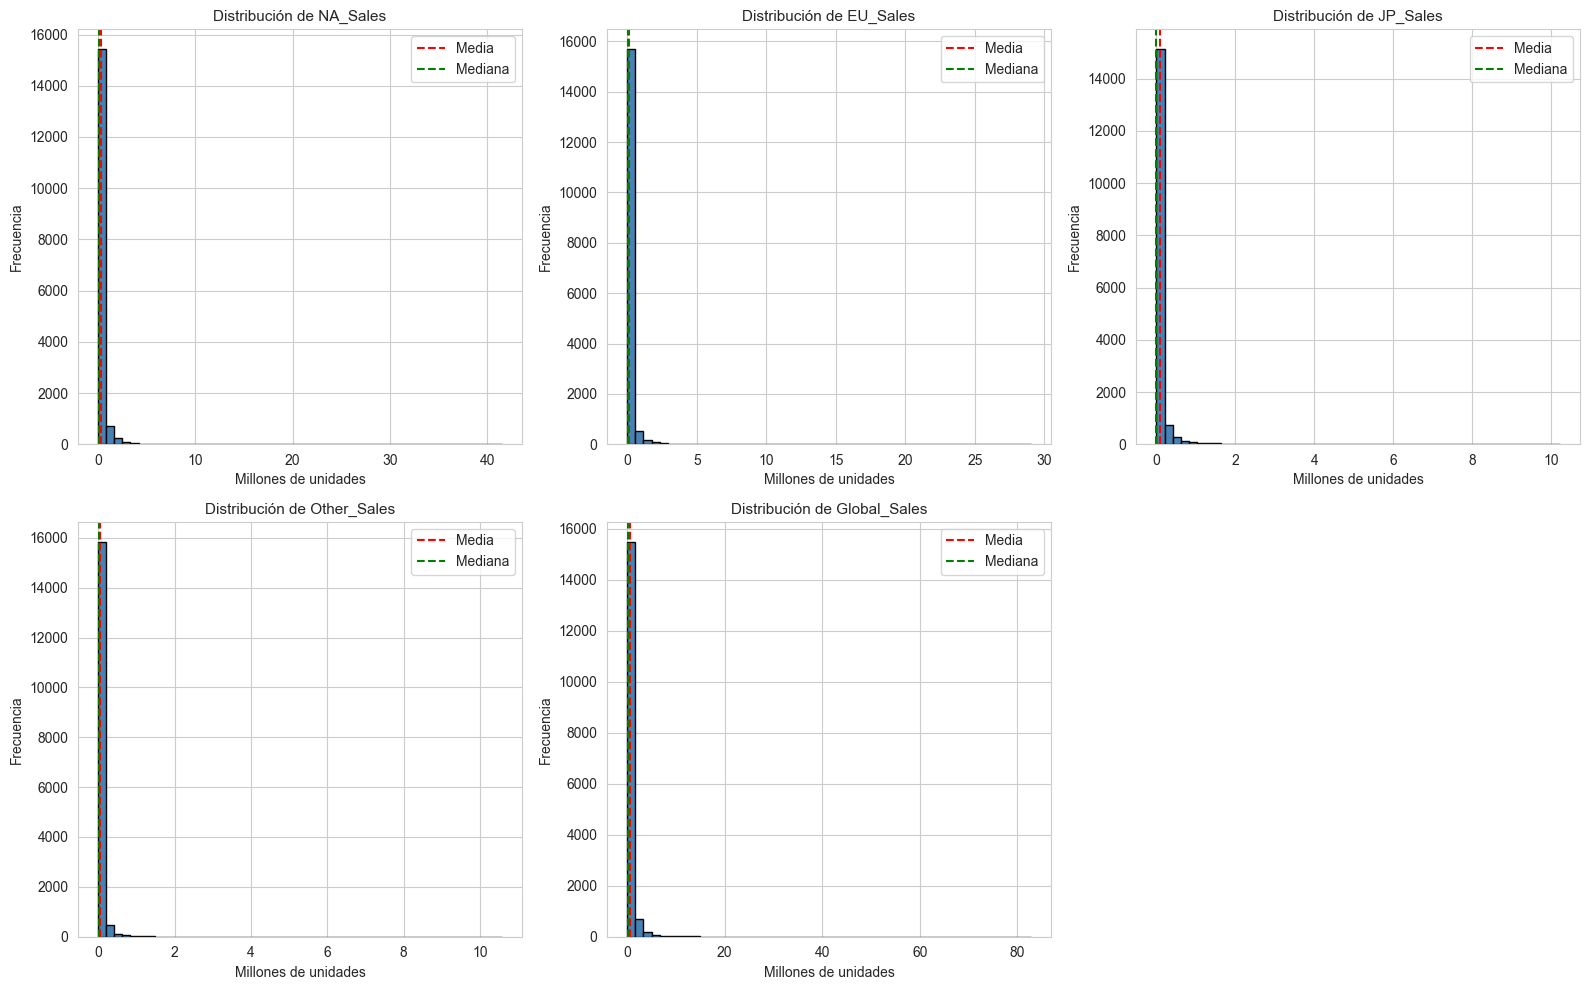

In [14]:
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(ventas):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribución de {col}', fontsize=11)
    axes[i].set_xlabel('Millones de unidades')
    axes[i].set_ylabel('Frecuencia')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Media')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Mediana')
    axes[i].legend()

axes[5].axis('off')
plt.tight_layout()
plt.show()

### Interpretación - Ventas por región

Todas las variables de ventas presentan una distribución fuertemente sesgada 
a la derecha. La media supera considerablemente a la mediana en todos los casos,
lo que indica que unos pocos juegos concentran la mayoría de las ventas globales.
Esto sugiere la presencia de outliers superiores que serán tratados más adelante.
NA_Sales es la región con mayor volumen de ventas, seguida de EU_Sales y JP_Sales.

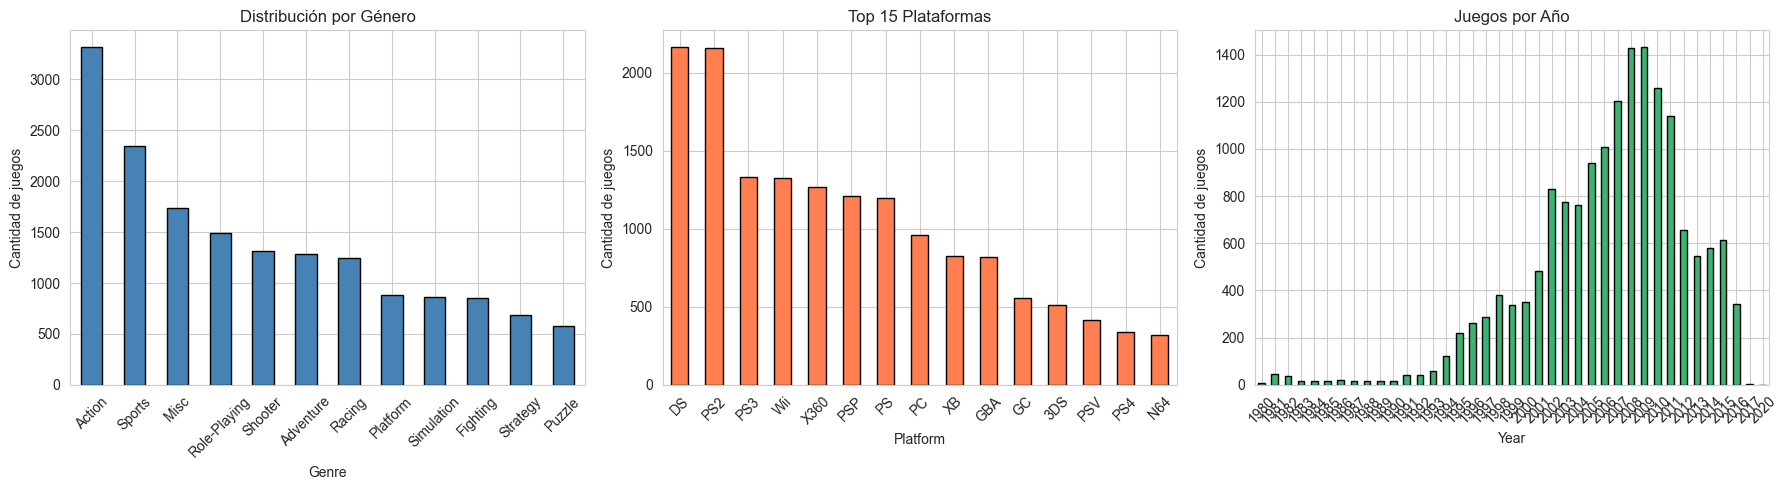

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Genre'].value_counts().plot(kind='bar', ax=axes[0], 
    color='steelblue', edgecolor='black')
axes[0].set_title('Distribución por Género', fontsize=12)
axes[0].set_ylabel('Cantidad de juegos')
axes[0].tick_params(axis='x', rotation=45)

df['Platform'].value_counts().head(15).plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='black')
axes[1].set_title('Top 15 Plataformas', fontsize=12)
axes[1].set_ylabel('Cantidad de juegos')
axes[1].tick_params(axis='x', rotation=45)

df['Year'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='black')
axes[2].set_title('Juegos por Año', fontsize=12)
axes[2].set_ylabel('Cantidad de juegos')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Interpretación - Variables categóricas y Year

**Género**: Action domina con más de 3,000 juegos, seguido de Sports y Misc.
Los géneros menos representados son Puzzle y Strategy.

**Plataformas**: DS y PS2 concentran la mayor cantidad de títulos, reflejando
su popularidad en la era de mayor producción de videojuegos (2000-2010).

**Año**: La industria tuvo un crecimiento sostenido desde 1980, alcanzando 
su pico en 2008-2009. La caída posterior puede deberse a que el dataset 
no tiene datos completos de años recientes, más que a una caída real del mercado.
```


### 2.2 Boxplots de ventas

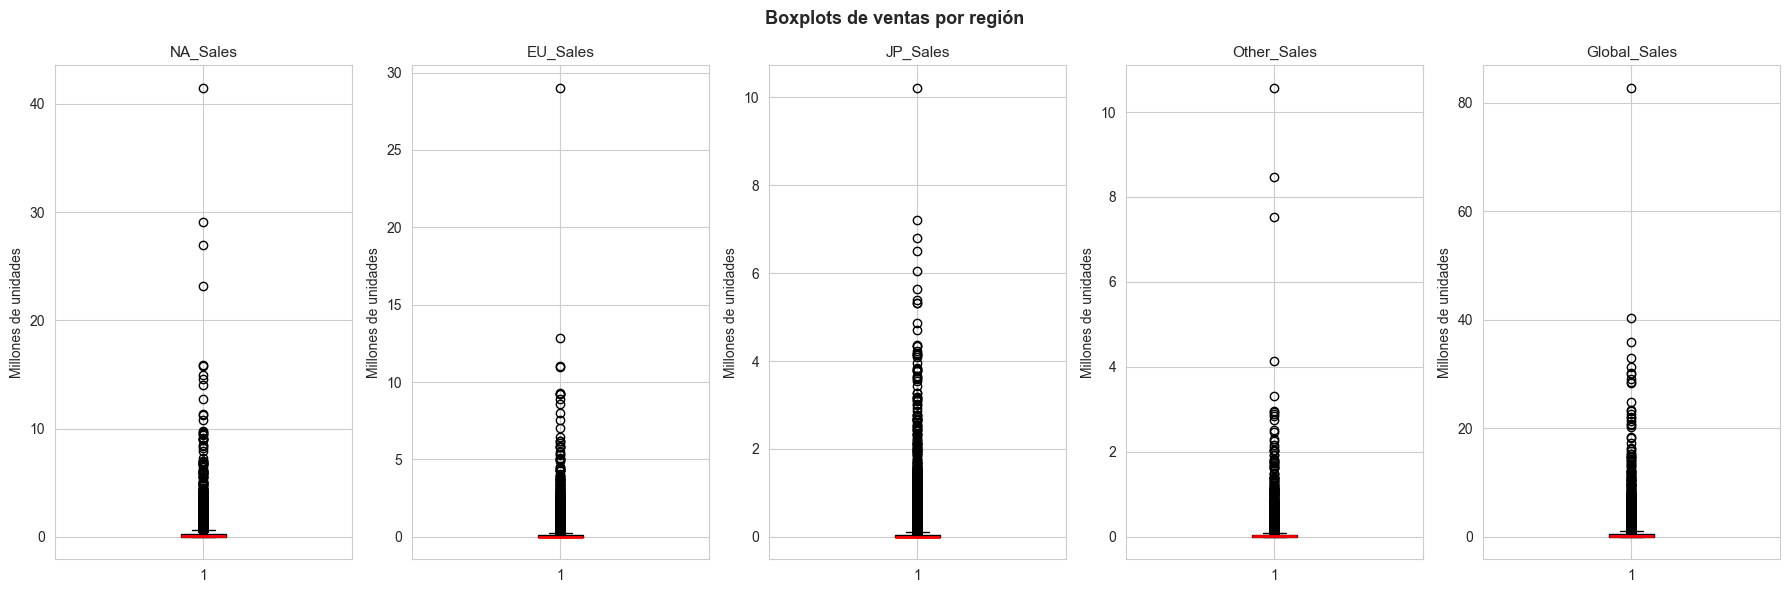

In [16]:
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(ventas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Millones de unidades')

plt.suptitle('Boxplots de ventas por región', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

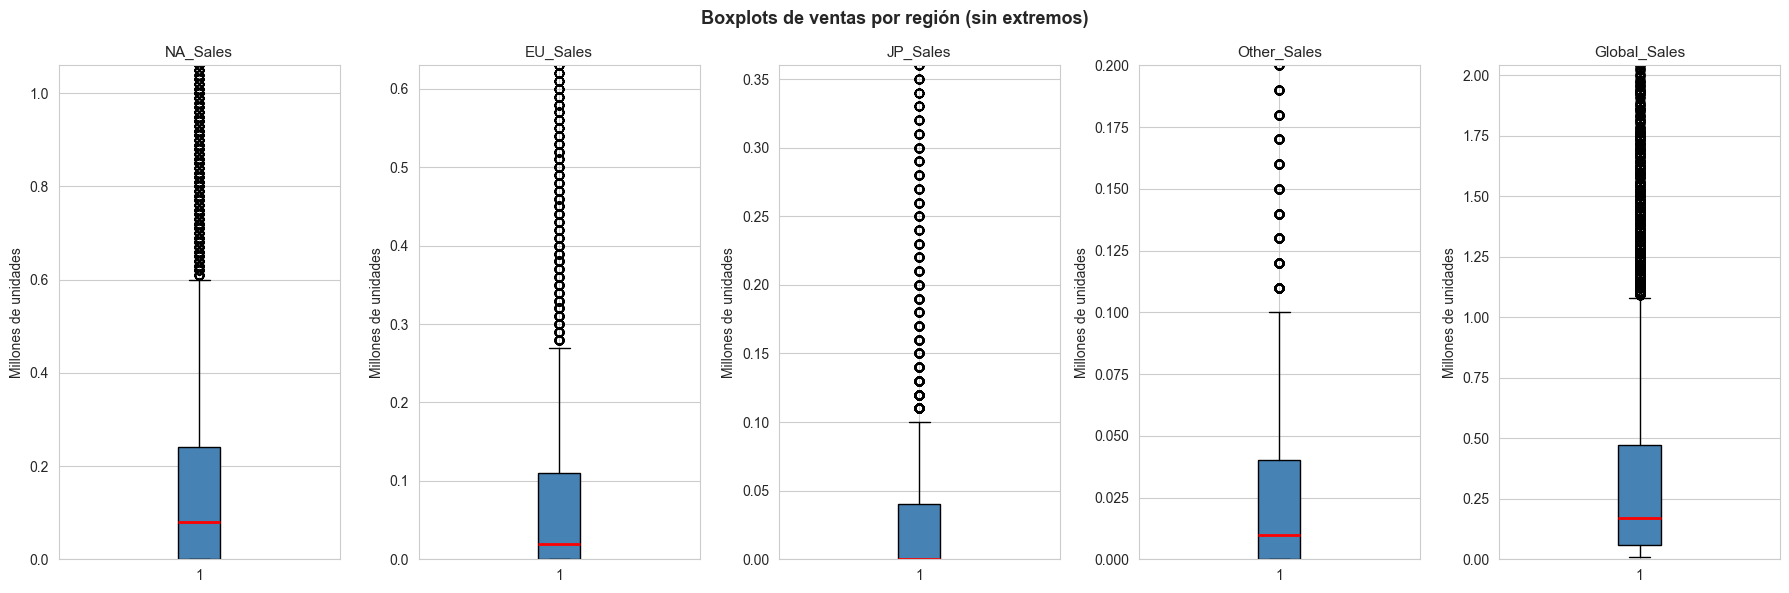

In [17]:
ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(1, 5, figsize=(18, 6))

for i, col in enumerate(ventas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Millones de unidades')
    axes[i].set_ylim(0, df[col].quantile(0.95))  # zoom al 95%

plt.suptitle('Boxplots de ventas por región (sin extremos)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación - Boxplots

Los boxplots confirman el sesgo detectado en los histogramas. La caja en todas 
las regiones está comprimida cerca de cero, indicando que el 75% de los juegos 
vende menos de 0.5M unidades. Los numerosos outliers superiores corresponden a 
títulos blockbuster como Wii Sports. Estos valores atípicos serán analizados 
en detalle en la sección de outliers.

In [18]:
from scipy import stats

ventas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

print("Pruebas de normalidad (Shapiro-Wilk):")
print(f"{'Variable':<15} {'Estadístico':>12} {'p-valor':>12} {'Normal?':>10}")
print("-" * 52)

for col in ventas:
    muestra = df[col].dropna().sample(5000, random_state=42)
    stat, p = stats.shapiro(muestra)
    normal = "Sí" if p > 0.05 else "No"
    print(f"{col:<15} {stat:>12.4f} {p:>12.6f} {normal:>10}")

Pruebas de normalidad (Shapiro-Wilk):
Variable         Estadístico      p-valor    Normal?
----------------------------------------------------
NA_Sales              0.2318     0.000000         No
EU_Sales              0.2030     0.000000         No
JP_Sales              0.2583     0.000000         No
Other_Sales           0.1764     0.000000         No
Global_Sales          0.2252     0.000000         No


### Interpretación - Pruebas de normalidad (Shapiro-Wilk)

Ninguna variable de ventas sigue una distribución normal (p-valor < 0.05 
en todos los casos). Esto era esperado dado el fuerte sesgo observado en 
los histogramas y boxplots. Esta característica es importante para la 
sección bivariada, donde se deberán usar pruebas no paramétricas 
(Spearman, Kruskal-Wallis) en lugar de pruebas paramétricas (Pearson, ANOVA).
```


## 3. Análisis Bivariado
### 3.1 Correlaciones entre variables numéricas

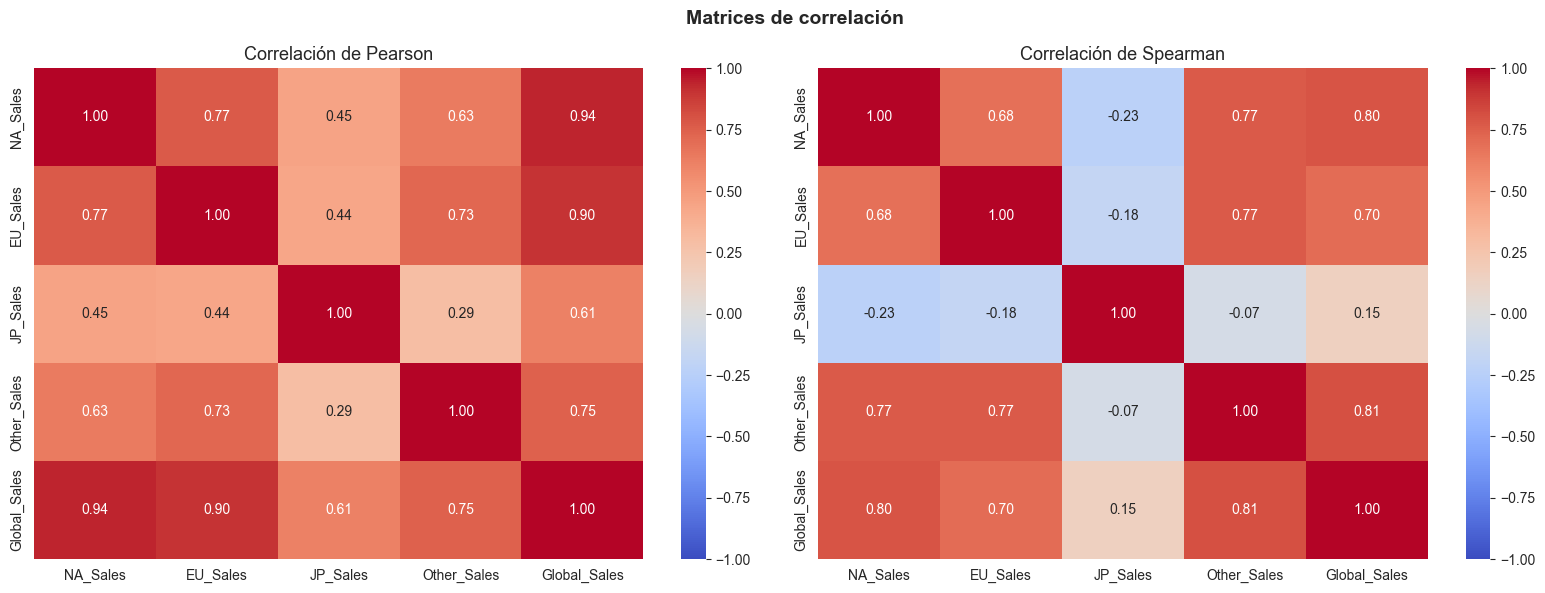

In [19]:
numericas = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_pearson = df[numericas].corr(method='pearson')
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlación de Pearson', fontsize=13)

corr_spearman = df[numericas].corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Correlación de Spearman', fontsize=13)

plt.suptitle('Matrices de correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación - Correlaciones

NA_Sales y EU_Sales tienen correlación muy alta con Global_Sales (0.94 y 0.90 
en Pearson), lo esperado ya que son las regiones dominantes. JP_Sales muestra 
correlaciones más bajas e incluso negativa con NA_Sales en Spearman (-0.23), 
sugiriendo que el mercado japonés tiene preferencias distintas. Dado que los 
datos no son normales, Spearman es el método más confiable para este dataset.

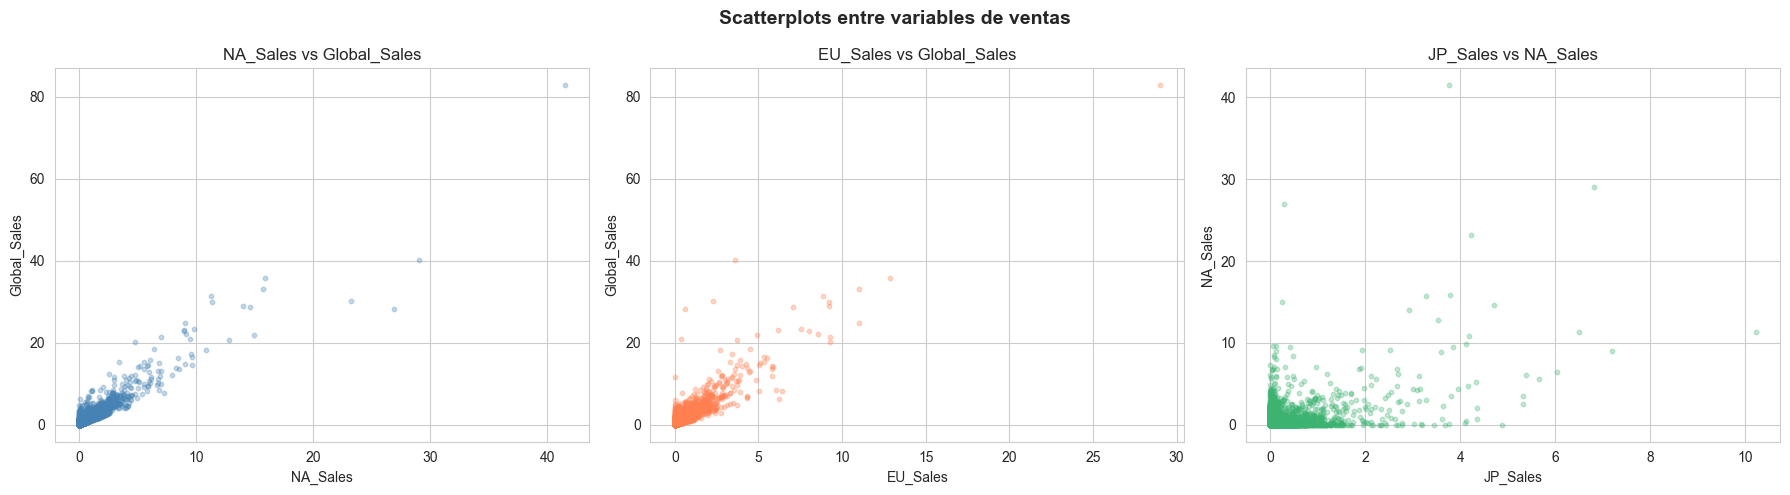

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['NA_Sales'], df['Global_Sales'], 
                alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('NA_Sales')
axes[0].set_ylabel('Global_Sales')
axes[0].set_title('NA_Sales vs Global_Sales', fontsize=12)

axes[1].scatter(df['EU_Sales'], df['Global_Sales'],
                alpha=0.3, color='coral', s=10)
axes[1].set_xlabel('EU_Sales')
axes[1].set_ylabel('Global_Sales')
axes[1].set_title('EU_Sales vs Global_Sales', fontsize=12)

axes[2].scatter(df['JP_Sales'], df['NA_Sales'],
                alpha=0.3, color='mediumseagreen', s=10)
axes[2].set_xlabel('JP_Sales')
axes[2].set_ylabel('NA_Sales')
axes[2].set_title('JP_Sales vs NA_Sales', fontsize=12)

plt.suptitle('Scatterplots entre variables de ventas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación - Scatterplots

NA_Sales y EU_Sales muestran una relación lineal clara con Global_Sales,
confirmando que estas regiones son los principales impulsores de las ventas 
globales. JP_Sales vs NA_Sales muestra dispersión sin patrón definido, 
reforzando que Japón opera como un mercado independiente con preferencias 
distintas al occidental.

/var/folders/9k/t9pn204110s4606rwknl6drm0000gn/T/ipykernel_59163/1509091998.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Genre', y='Global_Sales', order=orden,
/var/folders/9k/t9pn204110s4606rwknl6drm0000gn/T/ipykernel_59163/1509091998.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Platform', y='Global_Sales', order=orden_plat,


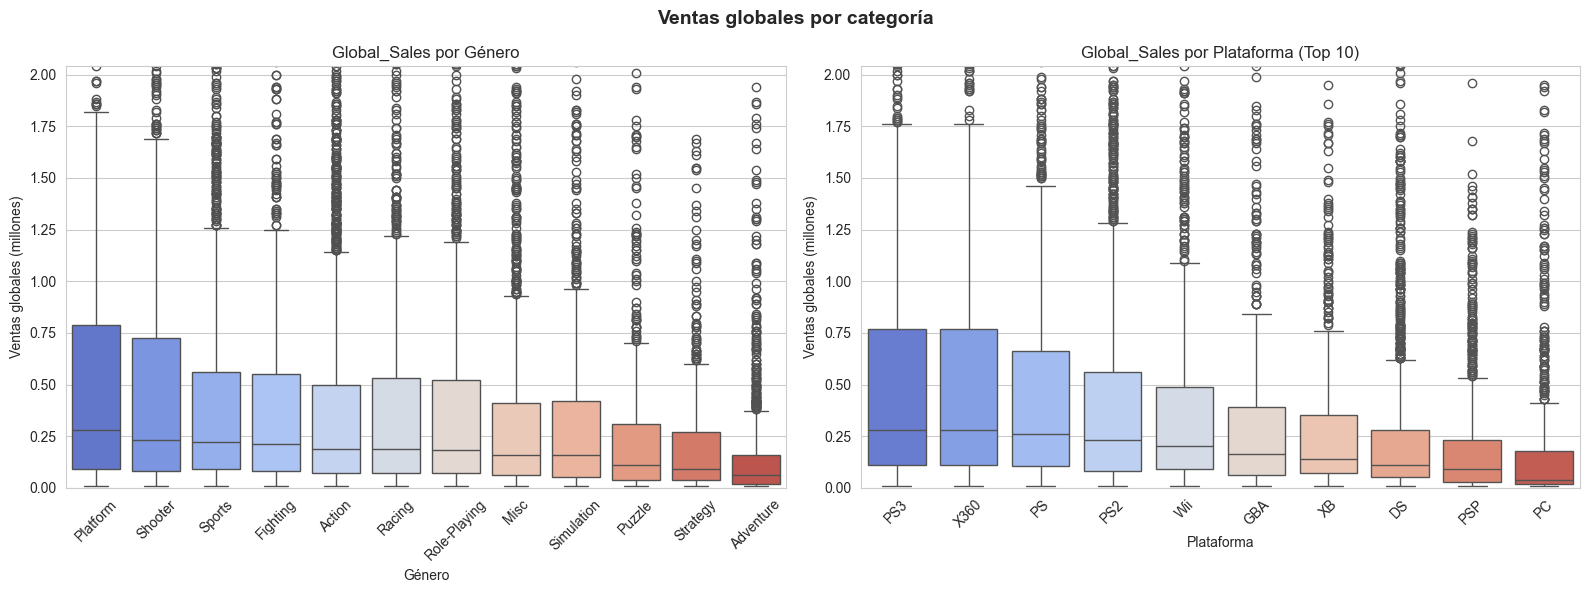

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

orden = df.groupby('Genre')['Global_Sales'].median().sort_values(ascending=False).index

sns.boxplot(data=df, x='Genre', y='Global_Sales', order=orden,
            ax=axes[0], palette='coolwarm')
axes[0].set_title('Global_Sales por Género', fontsize=12)
axes[0].set_xlabel('Género')
axes[0].set_ylabel('Ventas globales (millones)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, df['Global_Sales'].quantile(0.95))

top_plataformas = df['Platform'].value_counts().head(10).index
df_top = df[df['Platform'].isin(top_plataformas)]
orden_plat = df_top.groupby('Platform')['Global_Sales'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x='Platform', y='Global_Sales', order=orden_plat,
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Global_Sales por Plataforma (Top 10)', fontsize=12)
axes[1].set_xlabel('Plataforma')
axes[1].set_ylabel('Ventas globales (millones)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, df['Global_Sales'].quantile(0.95))

plt.suptitle('Ventas globales por categoría', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación - Boxplots por categoría

Por género, Platform y Shooter lideran en ventas globales medianas, mientras 
Adventure y Strategy tienen el menor rendimiento. Por plataforma, PS3 y X360 
muestran las medianas más altas, reflejando la era dorada de los videojuegos 
(2005-2012). Wii presenta outliers extremos debido a títulos como Wii Sports.
En todos los casos se observan outliers superiores, confirmando la distribución 
asimétrica del mercado.

### 3.2 Prueba de Kruskal-Wallis

In [23]:
from scipy.stats import kruskal

print("Prueba de Kruskal-Wallis - Global_Sales por categoría")
print("=" * 55)

grupos_genero = [group['Global_Sales'].values 
                 for name, group in df.groupby('Genre')]
stat, p = kruskal(*grupos_genero)
print(f"\nPor Género:")
print(f"  Estadístico: {stat:.4f}")
print(f"  p-valor:     {p:.6f}")
print(f"  Diferencia significativa: {'Sí' if p < 0.05 else 'No'}")

grupos_plat = [group['Global_Sales'].values 
               for name, group in df_top.groupby('Platform')]
stat2, p2 = kruskal(*grupos_plat)
print(f"\nPor Plataforma (Top 10):")
print(f"  Estadístico: {stat2:.4f}")
print(f"  p-valor:     {p2:.6f}")
print(f"  Diferencia significativa: {'Sí' if p2 < 0.05 else 'No'}")

Prueba de Kruskal-Wallis - Global_Sales por categoría

Por Género:
  Estadístico: 970.4532
  p-valor:     0.000000
  Diferencia significativa: Sí

Por Plataforma (Top 10):
  Estadístico: 1276.5045
  p-valor:     0.000000
  Diferencia significativa: Sí


### Interpretación - Kruskal-Wallis

La prueba confirma diferencias estadísticamente significativas en Global_Sales 
tanto por género (p < 0.05) como por plataforma (p < 0.05). Esto significa que 
el género y la plataforma son variables relevantes para explicar las ventas, 
y deben considerarse en el análisis posterior..
```